In [17]:
# Install libraries
!pip install -U sentence-transformers seaborn matplotlib

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

In [18]:
# 10 sentences: 3 Cricket, 4 Cooking, 3 Cybersecurity
sentences = [
    "The batsman hit a magnificent six over the long-on boundary.",
    "The pitch seems to favor spinners in the second innings of the match.",
    "Fielders were placed strategically to stop the captain from scoring runs.",
    "Whisk the eggs and sugar together until the mixture is light and fluffy.",
    "Slow-cooking the meat ensures it remains tender and full of flavor.",
    "Add a pinch of sea salt and fresh herbs to enhance the aroma of the sauce.",
    "Preheat the oven to 180°C before placing the baking tray inside.",
    "Multi-factor authentication adds an essential layer of security to accounts.",
    "Encryption algorithms are used to protect sensitive data from unauthorized access.",
    "A firewall monitors incoming and outgoing network traffic to block threats."
]

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


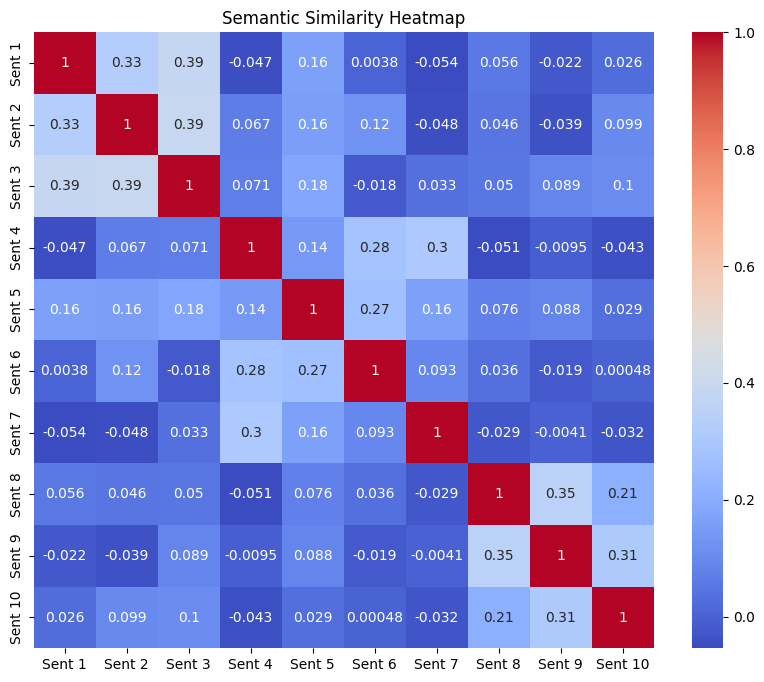

In [19]:
cosine_scores = util.cos_sim(embeddings, embeddings).cpu().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores, annot=True, cmap='coolwarm',
            xticklabels=[f"Sent {i+1}" for i in range(10)],
            yticklabels=[f"Sent {i+1}" for i in range(10)])
plt.title("Semantic Similarity Heatmap")
plt.show()

In [20]:
query = "The bowler took three wickets in one over"
query_emb = model.encode(query, convert_to_tensor=True)
scores = util.cos_sim(query_emb, embeddings)[0]
top_2_idx = np.argsort(scores.cpu().numpy())[::-1][:2]

print(f"Query: {query}\n" + "="*40)
for idx in top_2_idx:
    print(f"Match: {sentences[idx]}")
    print(f"Score: {scores[idx]:.4f}\n")

Query: The bowler took three wickets in one over
Match: The batsman hit a magnificent six over the long-on boundary.
Score: 0.5387

Match: The pitch seems to favor spinners in the second innings of the match.
Score: 0.4058

